In [ ]:
import warnings
from scipy.stats import weibull_min
import numpy as np
from empiricaldist import Cdf
import seaborn as sns
from utils import decorate, make_uniform, make_joint, normalize, plot_contour

sns.set_style('darkgrid')
warnings.filterwarnings("ignore")

## 1. The Weibull Distribution

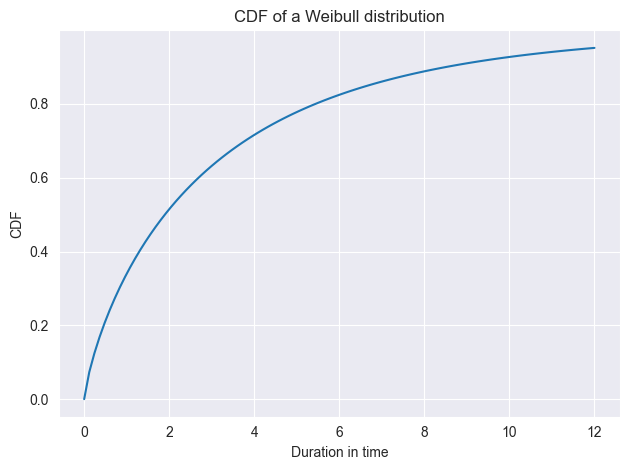

In [6]:
def weibull_dist(lamda_, k):
    return weibull_min(k, scale=lamda_)


lamda_ = 3
k = 0.8
actual_dist = weibull_dist(lamda_, k)

qs = np.linspace(0, 12, 101)
ps = actual_dist.cdf(qs)
cdf = Cdf(ps, qs)
cdf.plot()

decorate(
    xlabel='Duration in time', 
    ylabel='CDF',
    title='CDF of a Weibull distribution'
)

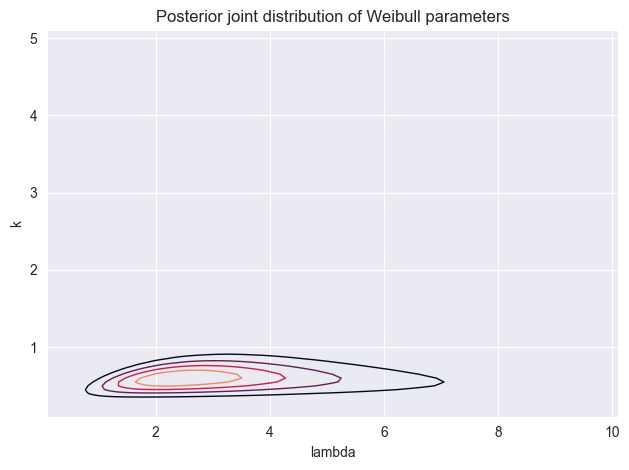

In [16]:
data = actual_dist.rvs(10)

lambdas = np.linspace(0.1, 10.1, num=101)
prior_lam = make_uniform(lambdas, name='lambda')

ks = np.linspace(0.1, 5.1, num=101)
prior_k = make_uniform(ks, name='k')

prior = make_joint(prior_lam, prior_k)

lamda_mesh, k_mesh, data_mesh = np.meshgrid(
    prior.columns, prior.index, data
)

densities = weibull_dist(lamda_mesh, k_mesh).pdf(data_mesh)
likelihood = densities.prod(axis=2)
posterior = prior * likelihood
normalize(posterior)


def update_weibull(prior, data):
    """Update the prior based on data."""
    lam_mesh, k_mesh, data_mesh = np.meshgrid(
        prior.columns, prior.index, data
    )
    
    densities = weibull_dist(lam_mesh, k_mesh).pdf(data_mesh)
    likelihood = densities.prod(axis=2)

    posterior = prior * likelihood
    normalize(posterior)

    return posterior


posterior = update_weibull(prior, data)
plot_contour(posterior)
decorate(title='Posterior joint distribution of Weibull parameters')